# Reporduce graphs for the papaer

This notebook reproduces the clustering analysis from `Pricescraper/6_analysis/cluster_market_personalities.py` and displays all figures inline. It also writes the same outputs to `reports/figures/cluster_market_personalities/` for record keeping.


In [ ]:
# Imports and module loader
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import importlib.util

# Notebook is in the same folder as the module
module_path = Path('scripts/cluster_market_personalities.py')
spec = importlib.util.spec_from_file_location('scripts/cluster_market_personalities', str(module_path))
cmp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cmp)

figures_dir = Path('../../reports/figures/cluster_market_personalities')
# Output directory used by the script
figures_dir.mkdir(parents=True, exist_ok=True)

# Override seaborn styling from imported module with simple matplotlib style
plt.style.use('default')  # Use default matplotlib style
plt.rcParams.update(plt.rcParamsDefault)  # Reset to default matplotlib parameters




In [2]:
# Default plot parameters
grid_alpha = 0.5
fill_alpha = 0.2
color_ecobee = "#840404"
color_bosch = "gray"
fontsize = 14

def get_color_dict():
    '''
    Returns: 
        a dictionary with colors that can be used to create nice plots with matplotlib (i.e. for handing over to the parameter color=...)
    '''
    return {
        'color_light': '#c2d0d4',
        'color_dark': '#35626f',
        'color_red': '#E55451',
        'color_yellow': cm.cividis(0.70),
        'color_blue': cm.viridis(0.50),
        'color_green': cm.viridis(0.30),
        'color_purple': cm.viridis_r(1.0),
    }

# Set global parameters
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (6, 5)  # can override with default_figsize when plotting
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=list(get_color_dict().values()))
plt.rcParams['axes.titlesize'] = fontsize + 2  # Set default title size
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = fontsize - 2  # Set default legend font size
plt.rcParams['axes.grid'] = True  # Set grid to always appear
plt.rcParams['figure.autolayout'] = True  # Set layout to be tight

pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 50)


In [3]:
# Ensure working directory is the project root so relative data paths work
needed = Path('data/processed/filtered_hplib_w_prices_and_decoding.csv')
if not needed.exists():
    # Walk up to 6 levels to find the repo root containing 'data/processed/...'
    cur = Path.cwd()
    for _ in range(6):
        candidate = cur / needed
        if candidate.exists():
            os.chdir(cur)
            break
        cur = cur.parent

df = cmp.load_data()
display(df.head())
print(f"Loaded {len(df)} rows and {df.shape[1]} columns")


,Manufacturer,Model,Titel,Date,Model/Type,Price,Currency,Website,Date_scraped,Type,Subtype,Group,Config,Storage,Storage Size (L),Rated Power low T [kW],Rated Power medium T [kW],Refrigerant,Mass of Refrigerant [kg],SPL indoor low Power [dBA],SPL outdoor low Power [dBA],SPL indoor high Power [dBA],SPL outdoor high Power [dBA],Bivalence temperature [°C],Tolerance temperature [°C],Max. water heating temperature [°C],Power heating rod low T [kW],Power heating rod medium T [kW],Poff [W],PTOS [W],PSB [W],PCKS [W],eta low T [%],eta medium T [%],SCOP,SEER low T,SEER medium T,P_th_h_ref [W],P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref
0,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS6800iAW 7 ORE-S,30.03.2023,Bosch Set BOPA CS772 AW 7 OR-S CS6800iAW 12 E ...,9933.0,EUR,idealo,2025-03-14,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,0.0,6.6,6.6,R290,"0,950 kg",31.0,42.0,31.0,42.0,-7.0,-10.0,75.0,0.74,1.39,15.0,15.0,15.0,32.0,180.0,138.0,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN
1,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORM-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS761 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,warm-water tank,170.0,4.4,4.0,R290,"0,950 kg",37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,0.79,0.90,15.0,14.0,15.0,33.0,179.0,127.0,4.55,NaN,NaN,3510.0,NaN,1671.0,NaN,2.10,NaN
2,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 5 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS774 AW 5 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.2,6.2,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.76,1.12,16.0,16.0,16.0,31.0,179.0,136.0,4.55,NaN,NaN,5530.0,NaN,2646.0,NaN,2.09,NaN
3,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS776 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,4.4,4.0,R290,"0,950 kg",37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,0.78,0.87,15.0,14.0,15.0,33.0,179.0,128.0,4.55,NaN,NaN,3530.0,NaN,1673.0,NaN,2.11,NaN
4,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 7 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS775 AW 7 OR...,11499.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.74,1.41,15.0,15.0,15.0,32.0,180.0,136.0,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN


Loaded 696 rows and 43 columns


In [4]:
new_df = df[df['Titel'].str.contains('WLW186i-7', na=False)]
new_df

,Manufacturer,Model,Titel,Date,Model/Type,Price,Currency,Website,Date_scraped,Type,Subtype,Group,Config,Storage,Storage Size (L),Rated Power low T [kW],Rated Power medium T [kW],Refrigerant,Mass of Refrigerant [kg],SPL indoor low Power [dBA],SPL outdoor low Power [dBA],SPL indoor high Power [dBA],SPL outdoor high Power [dBA],Bivalence temperature [°C],Tolerance temperature [°C],Max. water heating temperature [°C],Power heating rod low T [kW],Power heating rod medium T [kW],Poff [W],PTOS [W],PSB [W],PCKS [W],eta low T [%],eta medium T [%],SCOP,SEER low T,SEER medium T,P_th_h_ref [W],P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref
69,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR TP70,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,9507.8,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.74,1.41,15.0,15.0,15.0,32.0,180.0,136.0,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN
70,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR TP70 W,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,9507.8,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.74,1.41,15.0,15.0,15.0,32.0,180.0,136.0,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN
87,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR E,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,7689.7,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,0.0,6.6,6.6,R290,"0,950 kg",31.0,42.0,31.0,42.0,-7.0,-10.0,75.0,0.74,1.39,15.0,15.0,15.0,32.0,180.0,138.0,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN
88,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR E W,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,7689.7,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,0.0,6.6,6.6,R290,"0,950 kg",31.0,42.0,31.0,42.0,-7.0,-10.0,75.0,0.74,1.39,15.0,15.0,15.0,32.0,180.0,138.0,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN
95,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR T180,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,10683.5,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,warm-water tank,180.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.75,1.44,15.0,15.0,15.0,32.0,179.0,136.0,4.56,NaN,NaN,5900.0,NaN,2850.0,NaN,2.07,NaN
96,Bosch Thermotechnik GmbH (Buderus),Buderus Logatherm WLW MB-4/5/7 AR,Logatherm WLW186i-7 AR T180 W,30.03.2023,Buderus Luft-Wasser-Wärmepumpe Logaplus WLW186...,10683.5,EUR,heima24,2025-04-10,Outdoor Air/Water,Regulated,1.0,monoblock,warm-water tank,180.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.75,1.44,15.0,15.0,15.0,32.0,179.0,136.0,4.56,NaN,NaN,5900.0,NaN,2850.0,NaN,2.07,NaN


In [6]:
df.Subtype.value_counts()


Subtype
Regulated    684
On-Off        12
Name: count, dtype: int64

In [7]:
### Add some features

manufacturer_region_map = {
    'Bosch': 'European',
    'Viessmann': 'European',
    'AIT': 'European',
    'Buderus': 'European',
    'Vaillant': 'European',
    'Wolf': 'European',
    'Daikin': 'Japanese',
    'Mitsubishi': 'Japanese',
    'Panasonic': 'Japanese',
    'Toshiba': 'Japanese',
    'Johnson / Hitachi': 'Japanese',
    'Samsung': 'Korean',
    'LG': 'Korean'
}

def add_region_features(df, region_encoding='label'):
    """
    Add region features to df:
    - 'label' (default): Region column as current (European, Japanese, etc)
    - 'binary': Region_EU column is 1 if European, 0 otherwise
    """
    # Add categorical region label
    def get_region(manufacturer):
        for name, region in manufacturer_region_map.items():
            if name.lower() in (str(manufacturer) or "").lower():
                return region
        return "Other"
    
    if region_encoding == 'label':
        df["Region"] = df["Manufacturer"].apply(get_region)
    elif region_encoding == 'binary':
        df["Region"] = df["Manufacturer"].apply(
            lambda x: 1 if get_region(x) == 'European' else 0
        )
    else:
        raise ValueError("region_encoding must be either 'label' or 'binary'")
    return df

# Default: keep "Region" label as before
df = add_region_features(df, region_encoding='binary')




In [8]:
df.value_counts("Region")

Region
0    413
1    283
Name: count, dtype: int64

In [11]:
def clean_data(df):
    """Clean and prepare data for analysis"""
    # Convert numeric columns to proper types
    numeric_columns = ['Price', 'SCOP', 'Rated Power low T [kW]', 
                      'SPL outdoor high Power [dBA]', 'Max. water heating temperature [°C]']
    
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

In [12]:
def prepare_clustering_data(df):
    """Prepare and engineer features for clustering analysis"""
    print("Preparing data for clustering analysis...")
    
    # Clean the data
    df_clean = clean_data(df)
    
    print(f"Dataset after cleaning: {len(df_clean)} records")
    

    
    # Encode "Storage Size (L)" as 0 for "None", 0.5 for "Small (≤100L)", and 1 for "Large (>100L)" for easy interpretation
    if "Storage Size (L)" in df_clean.columns:
        storage_mapping = {"None": 0.0, "Small (≤100L)": 0.5, "Large (>100L)": 1.0}
        df_clean["Storage Size (L)"] = df_clean["Storage Size (L)"].map(storage_mapping)
    else:
        df_clean["Storage Size (L)"] = np.nan

    # Handle the Config column (convert to numeric: e.g. 0 for first kind, 1 for second)
    if "Config" in df_clean.columns:
        config_mapping = {"monoblock": 0.0, "split": 1.0}
        df_clean["Config"] = df_clean["Config"].map(config_mapping)
    else:
        df_clean["Config"] = np.nan

    # 3. Create clustering features (use the encoded Config value)
    clustering_features = {
        'SCOP': df_clean['SCOP'],
        'Noise_dBA': df_clean['SPL outdoor high Power [dBA]'],
        'Price_per_kW': df_clean['Price'] / df_clean['Rated Power low T [kW]'],
        'Max_Temp_C': df_clean['Max. water heating temperature [°C]'],
        'Rated_Power_kW': df_clean['Rated Power low T [kW]'],
        "Region": df_clean["Region"],  # Use encoded
        'Config': df_clean['Config'],  # Use encoded
        # 'Storage': df_clean['Storage'],
        'Storage Size (L)': df_clean['Storage Size (L)']
    }
    
    feature_df = pd.DataFrame(clustering_features)
    # Remove any rows with missing values in clustering features
    feature_df = feature_df.dropna()
    df_aligned = df_clean.loc[feature_df.index].copy()
    
    print(f"Final dataset: {len(feature_df)} products with {len(feature_df.columns)} features")
    
    # Display feature ranges
    print("Clustering features:")
    for col in feature_df.columns:
        # Only use .2f formatting for numeric (not categorical/object)
        col_data = feature_df[col]
        if np.issubdtype(col_data.dtype, np.number):
            print(f"  - {col}: {col_data.min():.2f} to {col_data.max():.2f}")
        else:
            print(f"  - {col}: {col_data.min()} to {col_data.max()}")
    
    return feature_df, df_aligned

In [13]:
# Prepare clustering data

feature_df, df_aligned = prepare_clustering_data(df)
print(f"Final dataset: {len(feature_df)} products with {len(feature_df.columns)} features")
display(feature_df.describe())
feature_df

Preparing data for clustering analysis...
Dataset after cleaning: 696 records
Final dataset: 696 products with 8 features
Clustering features:
  - SCOP: 3.84 to 5.45
  - Noise_dBA: 40.00 to 69.00
  - Price_per_kW: 330.00 to 2795.23
  - Max_Temp_C: 35.00 to 78.00
  - Rated_Power_kW: 3.44 to 13.00
  - Region: 0.00 to 1.00
  - Config: 0.00 to 1.00
  - Storage Size (L): 0.00 to 1.00
Final dataset: 696 products with 8 features


,SCOP,Noise_dBA,Price_per_kW,Max_Temp_C,Rated_Power_kW,Region,Config,Storage Size (L)
count,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000
mean,4.720905,54.647989,1135.937695,59.369253,8.251121,0.406609,0.464080,0.385776
std,0.237698,6.694006,386.069386,12.519803,2.512637,0.491554,0.499067,0.389002
min,3.840000,40.000000,330.000000,35.000000,3.440000,0.000000,0.000000,0.000000
25%,4.560000,52.000000,874.425502,55.000000,6.100000,0.000000,0.000000,0.000000
50%,4.680000,56.000000,1089.857143,60.000000,8.000000,0.000000,0.000000,0.500000
75%,4.900000,59.000000,1328.373106,70.000000,10.000000,1.000000,1.000000,0.500000
max,5.450000,69.000000,2795.227273,78.000000,13.000000,1.000000,1.000000,1.000000


,SCOP,Noise_dBA,Price_per_kW,Max_Temp_C,Rated_Power_kW,Region,Config,Storage Size (L)
0,4.58,42.0,1505.000000,75.0,6.6,1,0.0,0.0
1,4.55,40.0,2499.772727,75.0,4.4,1,0.0,0.5
2,4.55,42.0,1774.032258,75.0,6.2,1,0.0,0.5
3,4.55,40.0,2499.772727,75.0,4.4,1,0.0,0.5
4,4.56,42.0,1742.272727,75.0,6.6,1,0.0,0.5
...,...,...,...,...,...,...,...,...
691,4.75,54.0,1436.315789,60.0,9.5,1,0.0,0.0
692,4.90,54.0,757.789474,60.0,9.5,1,0.0,0.0
693,4.90,54.0,1010.421053,60.0,9.5,1,0.0,1.0
694,4.75,54.0,1646.000000,60.0,9.5,1,0.0,0.5


In [15]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)
feature_names = feature_df.columns.tolist()

X_scaled[:3], feature_names


(array([[-0.5932171 , -1.89080853,  0.95663561,  1.24937973, -0.65759913,
          1.20804137, -0.93056528, -0.99241981],
        [-0.71951844, -2.18979813,  3.5351569 ,  1.24937973, -1.53380284,
          1.20804137, -0.93056528,  0.29384497],
        [-0.71951844, -1.89080853,  1.65398626,  1.24937973, -0.81690889,
          1.20804137, -0.93056528,  0.29384497]]),
 ['SCOP',
  'Noise_dBA',
  'Price_per_kW',
  'Max_Temp_C',
  'Rated_Power_kW',
  'Region',
  'Config',
  'Storage Size (L)'])

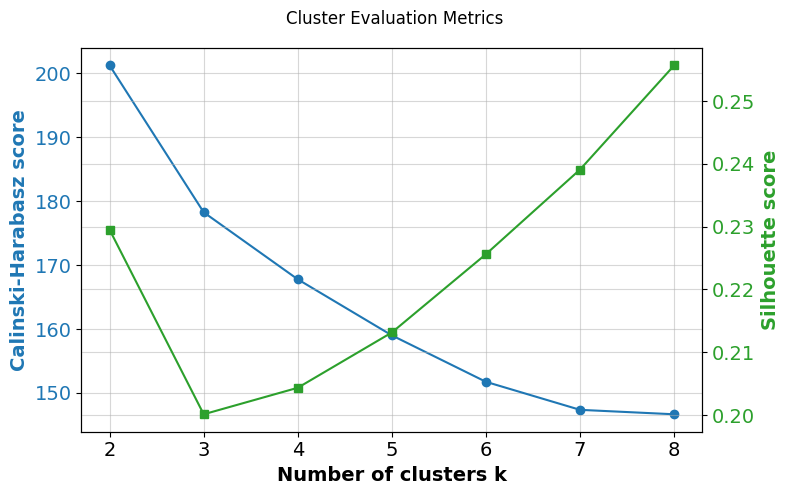

Selected k based on Calinski-Harabasz index: 2
Best k based on Silhouette score: 8 (score=0.256)


In [16]:
# Select optimal cluster number based on Calinski-Harabasz index and Silhouette score, and plot the results

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
import matplotlib.pyplot as plt

max_clusters = 8
ch_scores = []
sil_scores = []
k_range = range(2, max_clusters + 1)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    ch = calinski_harabasz_score(X_scaled, labels)
    sil = silhouette_score(X_scaled, labels)
    ch_scores.append(ch)
    sil_scores.append(sil)

# Plot CH and Silhouette scores
fig, ax1 = plt.subplots(figsize=(8,5))
color_ch = 'tab:blue'
color_sil = 'tab:green'

ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Calinski-Harabasz score', color=color_ch)
ax1.plot(list(k_range), ch_scores, marker='o', color=color_ch, label='Calinski-Harabasz')
ax1.tick_params(axis='y', labelcolor=color_ch)
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette score', color=color_sil)
ax2.plot(list(k_range), sil_scores, marker='s', color=color_sil, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color_sil)
fig.suptitle('Cluster Evaluation Metrics')
fig.tight_layout()
plt.show()

# Find the number of clusters with the maximum CH score
selected_k = k_range[ch_scores.index(max(ch_scores))]
print(f'Selected k based on Calinski-Harabasz index: {selected_k}')

# Also print the optimal silhouette k for information
best_sil_k = k_range[sil_scores.index(max(sil_scores))]
print(f'Best k based on Silhouette score: {best_sil_k} (score={max(sil_scores):.3f})')


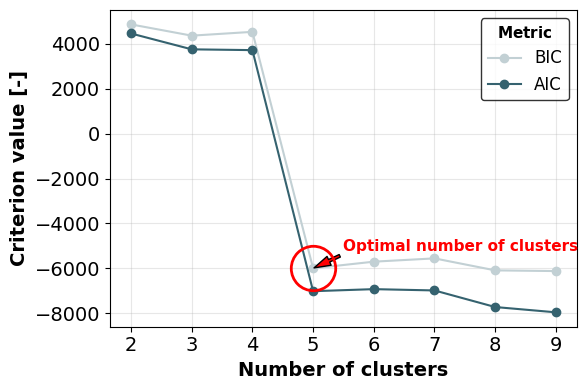

Optimal number of clusters by BIC: 9
Optimal number of clusters by AIC: 9


In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt



n_components_range = range(2, 10)
bics = []
aics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

fig = plt.figure(figsize=(6,4), facecolor='white')
ax = fig.add_subplot(111)
ax.set_facecolor('white')  # Make the subplot background white

ax.plot(n_components_range, bics, label='BIC', marker='o')
ax.plot(n_components_range, aics, label='AIC', marker='o')
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Criterion value [-]")
# ax.set_title("Model Selection for GMM")
legend = ax.legend(title=r"$\bf{Metric}$", facecolor='white', edgecolor='black', frameon=True, title_fontproperties={'weight': 'bold', "size": 11})
ax.grid(True, alpha=0.3)
fig.patch.set_facecolor('white')

# Annotate and highlight elbow/optimal k: biggest drop
# We'll use BIC as the main criterion, but you may adapt to AIC as needed

def find_biggest_drop(values):
    """Return the index where the biggest drop occurs"""
    diffs = np.diff(values)
    drop_idx = np.argmin(diffs)    # Most negative difference
    return drop_idx + 1  # +1 as diff is n-1 long

drop_k_bic = find_biggest_drop(bics)
optimal_k = n_components_range[drop_k_bic]
optimal_bic = bics[drop_k_bic]


# Draw a much bigger red circle around the selected point (larger ms)
ax.plot(optimal_k, optimal_bic, 'o', ms=32, mfc='none', mec='red', mew=2, zorder=5)

# Annotate on plot
ax.annotate("Optimal number of clusters",
            xy=(optimal_k, optimal_bic),
            xytext=(optimal_k+0.5, optimal_bic + (max(bics)-min(bics)) * 0.07),
            arrowprops=dict(facecolor='red', shrink=0.03, width=2, headwidth=7),
            fontsize=11, fontweight='bold', color='red'
           )

plt.show()

best_n_bic = n_components_range[np.argmin(bics)]
best_n_aic = n_components_range[np.argmin(aics)]

In [18]:
def determine_cluster_archetype(profile, df_all):
    """
    Determine cluster archetype based on characteristics, now also including
    region, tank size, and configuration.

    Prioritization logic:
    1. Special applications (Retrofit) take highest priority
    2. Region differentiation
    3. Price positioning (Budget/Premium) comes next
    4. Performance characteristics (Efficient, Quiet)
    5. Size/power and tank size/configuration characteristics
    6. Value propositions are used as modifiers
    """

    # Calculate percentiles relative to full dataset
    all_prices = df_all['Price']
    all_scop = df_all['SCOP']
    all_noise = df_all['SPL outdoor high Power [dBA]']
    all_power = df_all['Rated Power low T [kW]']
    all_price_per_kw = df_all['Price'] / df_all['Rated Power low T [kW]']
    all_regions = df_all['Region']
    all_storage = df_all['Storage Size (L)']
    all_config = df_all['Config'] 

    price_pct = (all_prices <= profile['avg_price']).mean()
    scop_pct = (all_scop <= profile['avg_scop']).mean()
    noise_pct = (all_noise <=profile['avg_noise']).mean()  # Higher percentile = noisier cluster
    power_pct = profile['avg_power'].mean()
    price_per_kw_pct = (all_price_per_kw <= profile['avg_price_per_kw']).mean()
    region_pct = profile['region'].mean()
    storage_pct = profile['avg_tank'].mean()
    config_pct = profile['avg_config'].mean()

    print("noise_pct", noise_pct)


    # Define thresholds
    LOW_THRESHOLD = 0.2  # e.g. budget below 40th percentile
    HIGH_THRESHOLD = 0.8

    # Categorize characteristics
    price_cat = "Budget" if price_pct < LOW_THRESHOLD else ("Premium" if price_pct > HIGH_THRESHOLD else "Mid-Range")
    efficiency_cat = "High-Efficiency" if scop_pct > HIGH_THRESHOLD else ("Standard" if scop_pct > LOW_THRESHOLD else "Basic")
    noise_cat = "Quiet" if noise_pct < LOW_THRESHOLD else ("Standard" if noise_pct < HIGH_THRESHOLD else "Noisy")
    size_cat = "Small" if power_pct < LOW_THRESHOLD else ("Large" if power_pct > HIGH_THRESHOLD else "Medium")
    value_cat = "Rather expensive" if price_per_kw_pct < LOW_THRESHOLD else ("Premium" if price_per_kw_pct > HIGH_THRESHOLD else "Standard")
    region_cat = "non-EU" if region_pct < LOW_THRESHOLD else("EU" if region_pct > HIGH_THRESHOLD else "Mixed")
    storage_cat = "No tank" if storage_pct < LOW_THRESHOLD else ("Large tank" if storage_pct > HIGH_THRESHOLD else "Medium")
    config_cat = "Monoblock" if config_pct < LOW_THRESHOLD else ("Split" if config_pct > HIGH_THRESHOLD else "Mixed")

    print("noise_cat", noise_cat)
    # Create archetype name *including* region, tank, config, using prioritization
    primary_traits = []

    # PRIORITY 2: Region
    if region_cat != "Mixed":
        primary_traits.append(region_cat)

    # # PRIORITY 3: Price positioning
    # if price_cat == "Budget":
    #     primary_traits.append("Budget")
    # elif price_cat == "Premium":
    #     primary_traits.append("Premium")
    # elif price_cat == "Mid-Range" and len(primary_traits) == 0:
    #     primary_traits.append("Mid-Range")



    if config_cat not in ["Mixed"]:
        primary_traits.append(config_cat)

    if profile['avg_max_temp'] > 65:
        primary_traits.append("Retrofit")
    if profile['avg_max_temp'] < 40:
        primary_traits.append("Modern house")

    # PRIORITY 4: Performance characteristics
    if efficiency_cat == "High-Efficiency":
        primary_traits.append("Efficient")

    if noise_cat == "Quiet":
        primary_traits.append("Quiet")

    if storage_cat == "Large tank":
        primary_traits.append("Large tank")
    if storage_cat == "No tank":
        primary_traits.append("No tank")


    # # PRIORITY 5: Size/power characteristics
    # if size_cat == "Compact":
    #     primary_traits.append("Compact")
    # elif size_cat == "Large":
    #     primary_traits.append("High-Power")



    # # PRIORITY 6: Value proposition (used as modifier)
    # if value_cat == "Value" and len(primary_traits) > 0:
    #     primary_traits.append("Value")
    
    


    print(primary_traits)

    # Construct name with combination rules, ensuring region/tank/config included
    if len(primary_traits) == 0:
        archetype = "Standard"
    elif len(primary_traits) == 1:
        archetype = primary_traits[0]
    else:
        # # Ensure any 'Retrofit' clusters keep priority
        # if "Retrofit" in primary_traits:
        #     other_traits = [t for t in primary_traits if t != "Retrofit"]
        #     if other_traits:
        #         archetype = f"Retrofit-{other_traits[0]}"
        #     else:
        #         archetype = "Retrofit-Specialist"
        # elif "Budget" in primary_traits and "Compact" in primary_traits:
        #     archetype = "Budget-Compact"
        # elif "Premium" in primary_traits and "Quiet" in primary_traits:
        #     archetype = "Premium-Quiet"
        # elif "Premium" in primary_traits and "Efficient" in primary_traits:
        #     archetype = "Premium-Efficient"
        # elif "Budget" in primary_traits and "Efficient" in primary_traits:
        #     archetype = "Budget-Efficient"
        # elif "Budget" in primary_traits and "Value" in primary_traits:
        #     archetype = "Budget-Value"
        # elif "Quiet" in primary_traits and "Value" in primary_traits:
        #     archetype = "Quiet-Value"
        # elif "Quiet" in primary_traits and "High-Power" in primary_traits:
        #     archetype = "Quiet-High-Power"
        # elif "Compact" in primary_traits and "Efficient" in primary_traits:
        #     archetype = "Compact-Efficient"
        # elif "Value" in primary_traits and "Efficient" in primary_traits:
        #     archetype = "Value-Efficient"
        # elif "Mid-Range" in primary_traits and "Efficient" in primary_traits:
        #     archetype = "Standard-Efficient"
        # elif "Mid-Range" in primary_traits:
        #     archetype = "Mid-Range-Standard"
        # else:
        #     # Default to combining top 2 traits
        archetype = "-".join(primary_traits[:4])
        print("archetype:",archetype)


    return archetype


def interpret_and_name_clusters(df_clustered, cluster_method="K-means"):
    """Interpret clusters and assign meaningful names without configuration analysis"""
    print(f"\nINTERPRETING AND NAMING CLUSTERS ({cluster_method})")
    print("="*80)
    
    cluster_names = {}
    cluster_profiles = {}
    
    for cluster_id in sorted(df_clustered['Cluster'].unique()):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id].copy()
        
        # Calculate cluster profile
        profile = {
            'size': len(cluster_data),
            'percentage': len(cluster_data) / len(df_clustered) * 100,
            'avg_price': cluster_data['Price'].mean(),
            'avg_scop': cluster_data['SCOP'].mean(),
            'avg_noise': cluster_data['SPL outdoor high Power [dBA]'].mean(),
            'avg_power': cluster_data['Rated Power low T [kW]'].mean(),
            'avg_max_temp': cluster_data['Max. water heating temperature [°C]'].mean(),
            'avg_price_per_kw': (cluster_data['Price'] / cluster_data['Rated Power low T [kW]']).mean(),
            'min_price': cluster_data['Price'].min(),
            'max_price': cluster_data['Price'].max(),
            'top_brands': cluster_data['Manufacturer'].value_counts().head(3),
            "region": cluster_data["Region"].mean(),
            "avg_tank": cluster_data["Storage Size (L)"].mean(),
            "avg_config": cluster_data["Config"].mean()
        }
        
        cluster_profiles[cluster_id] = profile
        
        # Determine archetype name
        archetype_name = determine_cluster_archetype(profile, df_clustered)
        cluster_names[cluster_id] = archetype_name
        
        # Display cluster analysis
        print(f"\nCLUSTER {cluster_id}: {archetype_name}")
        print("-" * 60)
        print(f"Size: {profile['size']} products ({profile['percentage']:.1f}%)")
        print(f"Price: {profile['avg_price']:,.0f} EUR (range: {profile['min_price']:,.0f} - {profile['max_price']:,.0f})")
        print(f"Efficiency (SCOP): {profile['avg_scop']:.2f}")
        print(f"Noise Level: {profile['avg_noise']:.1f} dBA")
        print(f"Power Rating: {profile['avg_power']:.1f} kW (range: {cluster_data['Rated Power low T [kW]'].min():.1f} - {cluster_data['Rated Power low T [kW]'].max():.1f})")
        print(f"Max Temperature: {profile['avg_max_temp']:.0f}°C")
        print(f"Price per kW: {profile['avg_price_per_kw']:,.0f} EUR/kW")
        print(f"Region: {profile['region']:,.0f}")

        
        # Top brands
        print(f"Leading brands: ", end="")
        brand_strs = []
        for brand, count in profile['top_brands'].items():
            brand_strs.append(f" {brand} ({count})")
        print(",".join(brand_strs))
        
        # Top refrigerants
        if 'Refrigerant' in cluster_data.columns:
            top_refrigerants = cluster_data['Refrigerant'].value_counts().head(3)
            print(f"Top refrigerants: ", end="")
            refrigerant_strs = []
            for ref, count in top_refrigerants.items():
                refrigerant_strs.append(f"{ref} ({count})")
            print(", ".join(refrigerant_strs))
        
        # Top configurations
        if 'Config' in cluster_data.columns and 'Storage' in cluster_data.columns:
            # Create configuration group for display, handling NaN values properly
            cluster_data = cluster_data.copy()
            # Replace NaN with 'Unknown' for display
            config_str = cluster_data['Config'].fillna('Unknown').astype(str)
            storage_str = cluster_data['Storage'].fillna('Unknown').astype(str)
            cluster_data['Config_Display'] = config_str + ' - ' + storage_str
            top_configs = cluster_data['Config_Display'].value_counts().head(3)
            print(f"Top configurations: ", end="")
            config_strs = []
            for config, count in top_configs.items():
                config_strs.append(f"{config} ({count})")
            print(", ".join(config_strs))
        
        # Generate buyer persona
        persona = generate_buyer_persona(profile, archetype_name)
        print(f"\nTARGET PERSONA: {persona}")
    
    return cluster_names, cluster_profiles


def perform_kmeans_clustering(X_scaled, df_aligned, n_clusters, feature_names):
    """Perform K-means clustering analysis.
    NOTE: Make sure df_aligned includes all original columns before encoding, if categorical columns like 'Config', 'Region', 'Manufacturer', etc. are required after clustering.
    If you encoded string/categorical columns for use in X_scaled, but then only keep those encoded columns, you will LOSE the original string/categorical columns when adding cluster assignments! 
    That can lead to NaNs or missing values in the categorical columns after inverse-transform attempts or when referencing those columns for reporting.
    To avoid this:
        - Always work on a copy of the pre-encoded dataframe for your cluster assignments (not just the encoded version), 
        - OR carry through (append) the original columns into your encoded dataframe before clustering.
    """

    print(f"\nPerforming K-means clustering with {n_clusters} clusters...")

    df_clustered = df_aligned.copy()

    # Fit K-means with KMeans's default parameters (which do NOT enforce even cluster sizes; clusters may be imbalanced)
    # Optionally, you could use other clustering methods if non-even sizes are preferred, e.g., GaussianMixture, DBSCAN, etc.

    # kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)  # No constraint on cluster size
    # cluster_labels = kmeans.fit_predict(X_scaled)
    # df_clustered['Cluster'] = cluster_labels

    from sklearn.mixture import GaussianMixture

    gmm = GaussianMixture(n_components=n_clusters, random_state=42, covariance_type='full')
    cluster_labels = gmm.fit_predict(X_scaled)
    df_clustered['Cluster'] = cluster_labels

    # You may want to double-check this point:
    # If you created X_scaled from a different DataFrame that does NOT include the original categorical columns, 
    # make sure df_aligned is the original (non-encoded) DataFrame so your cluster output retains all needed fields. 
    # If you used e.g. df_encoded for clustering, and df_encoded only contains numeric/one-hot columns, 
    # then result will lack the original string/categorical columns.

    print(f"\nCLUSTER ANALYSIS:")
    print("=" * 80)
    
    for i in range(n_clusters):
        cluster_data = df_clustered[df_clustered['Cluster'] == i]
        cluster_size = len(cluster_data)
        cluster_pct = cluster_size / len(df_clustered) * 100
        
        print(f"\nCLUSTER {i} ({cluster_size} products, {cluster_pct:.1f}%)")
        print("-" * 50)
        
        # Calculate cluster statistics for original features, handle missing columns gracefully
        stats = {
            'SCOP': cluster_data['SCOP'] if 'SCOP' in cluster_data.columns else None,
            'Noise_dBA': cluster_data['SPL outdoor high Power [dBA]'] if 'SPL outdoor high Power [dBA]' in cluster_data.columns else None,
            'Price_EUR': cluster_data['Price'] if 'Price' in cluster_data.columns else None,
            'Price_per_kW': (cluster_data['Price'] / cluster_data['Rated Power low T [kW]']) if 'Price' in cluster_data.columns and 'Rated Power low T [kW]' in cluster_data.columns else None,
            'Max_Temp_C': cluster_data['Max. water heating temperature [°C]'] if 'Max. water heating temperature [°C]' in cluster_data.columns else None,
            'Rated_Power_kW': cluster_data['Rated Power low T [kW]'] if 'Rated Power low T [kW]' in cluster_data.columns else None,
            'Region': cluster_data['Region'] if 'Region' in cluster_data.columns else None,
            'Config': cluster_data['Config'] if 'Config' in cluster_data.columns else None,
            'Storage Size (L)': cluster_data['Storage Size (L)'] if 'Storage Size (L)' in cluster_data.columns else None,
        }
        
        for feature, values in stats.items():
            if values is not None:
                # Check if the column is numeric
                if pd.api.types.is_numeric_dtype(values) and not values.isna().all():
                    mean_val = values.mean()
                    std_val = values.std()
                    print(f"  {feature:<15}: {mean_val:8.2f} ± {std_val:6.2f}")

            else:
                print(f"  {feature:<15}: Not available")
        
        # Most common brands, refrigerants, and configurations in this cluster
        if 'Manufacturer' in cluster_data.columns:
            top_brands = cluster_data['Manufacturer'].value_counts().head(3)
            print(f"  Top brands: {', '.join([f'{brand} ({count})' for brand, count in top_brands.items()])}")
        
        if 'Refrigerant' in cluster_data.columns:
            top_refrigerants = cluster_data['Refrigerant'].value_counts().head(3)
            print(f"  Top refrigerants: {', '.join([f'{ref} ({count})' for ref, count in top_refrigerants.items()])}")
        
        if 'Config' in cluster_data.columns and 'Storage' in cluster_data.columns:
            # Create configuration group for display, handling NaN values properly
            cluster_data = cluster_data.copy()  # Prevent SettingWithCopy warning
            # Replace NaN with empty string or 'Unknown' for display
            config_str = cluster_data['Config'].fillna('Unknown').astype(str)
            storage_str = cluster_data['Storage'].fillna('Unknown').astype(str)
            cluster_data['Config_Display'] = config_str + ' - ' + storage_str
            top_configs = cluster_data['Config_Display'].value_counts().head(3)
            print(f"  Top configurations: {', '.join([f'{config} ({count})' for config, count in top_configs.items()])}")

    # Interpret clusters and assign names
    cluster_names, cluster_profiles = interpret_and_name_clusters(df_clustered, f"K-means (k={n_clusters})")
    return df_clustered, cluster_names, cluster_profiles

In [19]:
def create_cluster_visualizations(df_clustered, X_scaled, feature_names, cluster_names, figures_dir, method="K-means"):
    """Create comprehensive visualizations for cluster analysis, with larger font sizes for readability"""
    print(f"\nCreating cluster visualizations for {method}...")

    # Larger fonts for all visuals
    big_title_size = fontsize + 12 -4
    mid_title_size = fontsize + 8-4
    label_size = fontsize + 6-4
    tick_size = fontsize + 4-4
    legend_size = fontsize + 3-4
    pie_pct_size = fontsize + 6-4

    # Use a more scientific, less colorful color palette (e.g., matplotlib's 'viridis')
    cmap = plt.cm.viridis
    n_clusters = df_clustered['Cluster'].nunique()
    # Use a list of colors from the colormap
    colors = [cmap(i) for i in np.linspace(0.2, 0.85, n_clusters)]

    # Create method-specific directory with safe name
    safe_method_name = method.lower().replace('-', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
    method_dir = figures_dir / safe_method_name
    method_dir.mkdir(parents=True, exist_ok=True)




    # 2. Feature Distribution by Cluster - Box Plots and Bar Charts
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    fig.suptitle(
        'k-Means Clustering - Feature Distributions', 
        fontsize=big_title_size, fontweight='bold', y=1.02
    )  # large title

    # Remove units from feature names for titles/ylabels
    # Define feature data, y-labels, and title names for each feature to plot
    boxplot_features = [
        {
            "feature_data": df_clustered['SCOP'],
            "ylabel": "SCOP [-]",
            "title": "SCOP",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['SPL outdoor high Power [dBA]'],
            "ylabel": "Noise [dBA]",
            "title": "Outdoor sound level",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Price'],
            "ylabel": "Price [EUR]",
            "title": "Total price",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Price'] / df_clustered['Rated Power low T [kW]'],
            "ylabel": "Price per kW [EUR/kW]",
            "title": "Price per kW",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Max. water heating temperature [°C]'],
            "ylabel": "Max temp [°C]",
            "title": "Max supply temperature",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Rated Power low T [kW]'],
            "ylabel": "Power [kW]",
            "title": "Rated power",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Storage Size (L)'],
            "ylabel": "Storage Size [L]",
            "title": "Storage tank size",
            "plot_type": "boxplot"
        },
        {
            "feature_data": df_clustered['Config'] if 'Config' in df_clustered.columns else None,
            "ylabel": "Count",
            "title": "Configuration",
            "plot_type": "bar"
        },
        {
            "feature_data": df_clustered['Region'] if 'Region' in df_clustered.columns else None,
            "ylabel": "Count",
            "title": "Region",
            "plot_type": "bar"
        },
    ]

    axes_flat = axes.flatten()
    for idx, feat in enumerate(boxplot_features):
        feature_data = feat["feature_data"]
        feature_name = feat["ylabel"]
        title = feat["title"]
        plot_type = feat.get("plot_type", "boxplot")
        ax = axes_flat[idx]

        if feature_data is None:
            ax.text(0.5, 0.5, "Data not available", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title, fontsize=mid_title_size, fontweight='bold')
            continue

        if plot_type == "boxplot":
            # Create box plot for numeric features
            cluster_data = []
            cluster_labels = []
            for i in range(n_clusters):
                mask = df_clustered['Cluster'] == i
                cluster_data.append(feature_data[mask])
                cluster_name = cluster_names.get(i, f"C{i}")
                display_name = cluster_name
                cluster_labels.append(f"{display_name}")

            bp = ax.boxplot(cluster_data, labels=cluster_labels, patch_artist=True)

            # Color boxes
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            ax.set_ylabel(feature_name, fontsize=label_size, fontweight='bold')
            
        elif plot_type == "bar":
            # Create bar chart for categorical features (Config, Region)
            # Count occurrences of each category in each cluster
            if title == "Configuration":
                categories = df_clustered['Config'].dropna().unique() if 'Config' in df_clustered.columns else []
            elif title == "Region":
                categories = df_clustered['Region'].dropna().unique() if 'Region' in df_clustered.columns else []
            else:
                categories = feature_data.dropna().unique()
            
            if len(categories) > 0:
                # Prepare data for grouped bar chart
                x_pos = np.arange(len(categories))
                width = 0.8 / n_clusters
                
                for i in range(n_clusters):
                    mask = df_clustered['Cluster'] == i
                    cluster_data = df_clustered.loc[mask]
                    counts = []
                    for cat in categories:
                        if title == "Configuration":
                            cat_counts = (cluster_data['Config'] == cat).sum() if 'Config' in cluster_data.columns else 0
                        elif title == "Region":
                            cat_counts = (cluster_data['Region'] == cat).sum() if 'Region' in cluster_data.columns else 0
                        else:
                            cat_counts = (cluster_data[feature_data.name if hasattr(feature_data, 'name') else title] == cat).sum()
                        counts.append(cat_counts)
                    
                    cluster_name = cluster_names.get(i, f"C{i}")
                    display_name = cluster_name
                    offset = (i - n_clusters/2 + 0.5) * width
                    ax.bar(x_pos + offset, counts, width, label=display_name, color=colors[i], alpha=0.7)
                
                ax.set_xticks(x_pos)
                ax.set_xticklabels(categories, rotation=35, ha='right', fontsize=tick_size-1)
                ax.set_ylabel(feature_name, fontsize=label_size, fontweight='bold')
                ax.legend(fontsize=legend_size, loc='upper right')
            else:
                ax.text(0.5, 0.5, "No data available", ha='center', va='center', transform=ax.transAxes)

        # Increase font sizes for all parts
        ax.set_title(title, fontsize=mid_title_size, fontweight='bold')
        ax.tick_params(axis='x', rotation=35, labelsize=tick_size -1)
        ax.tick_params(axis='y', labelsize=tick_size-1)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(method_dir / 'feature_distributions_boxplot.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 3. Improved Cluster Characteristics Radar Chart

    # Determine subplot grid (rows, cols) for up to 5 clusters + 1 pie chart
    max_radar = min(n_clusters, 5)
    total_plots = max_radar + 1  # +1 for pie chart

    # Grid logic: for exactly 3 radar plots, use 2x2, else usual 2x3 if >3, or 1x3 for <=2
    if max_radar == 3:
        n_rows_final, n_cols_final = (2, 2)
    elif total_plots > 3:
        n_rows_final, n_cols_final = (2, 3)
    else:
        n_rows_final, n_cols_final = (1, 3)

    fig, axes = plt.subplots(
        n_rows_final, n_cols_final,
        figsize=(18, 10 if n_rows_final == 1 else 12),
        subplot_kw=dict(projection='polar'),
        # gridspec_kw={'wspace': 0.25, 'hspace': 0.36}
    )

    # fig.suptitle(
    #     'Cluster characteristics',
    #     fontsize=big_title_size, fontweight='bold', y=1.02
    # )

    radar_features = [
        'SCOP', 'Quietness', 'Value', 'Max temp', 'Power', 'Affordability', "Region","Config", "Storage size (L)"
    ]
    radar_y_label = "Normalized Value"

    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Draw cluster radar charts
    for idx, cluster_id in enumerate(range(max_radar)):
        ax = axes_flat[idx]
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
        display_name = cluster_name

        # Set white background
        ax.set_facecolor('white')
        ax.figure.set_facecolor('white')

        # Normalized feature values
        values = []
        all_data = df_clustered

        # 1. SCOP
        scop_norm = (cluster_data['SCOP'].mean() - all_data['SCOP'].min()) / (all_data['SCOP'].max() - all_data['SCOP'].min())
        values.append(scop_norm)
        # 2. Quietness (inverse of noise)
        cluster_avg_noise = cluster_data['SPL outdoor high Power [dBA]'].mean()
        max_noise = all_data['SPL outdoor high Power [dBA]'].max()
        min_noise = all_data['SPL outdoor high Power [dBA]'].min()
        quietness_norm = (max_noise - cluster_avg_noise) / (max_noise - min_noise)
        values.append(quietness_norm)
        # 3. Value (inverse price per kW)
        price_per_kw = cluster_data['Price'] / cluster_data['Rated Power low T [kW]']
        all_price_per_kw = all_data['Price'] / all_data['Rated Power low T [kW]']
        value_inv = all_price_per_kw.max() - price_per_kw.mean()
        value_norm = value_inv / (all_price_per_kw.max() - all_price_per_kw.min())
        values.append(value_norm)
        # 4. Max Temp
        temp_norm = (cluster_data['Max. water heating temperature [°C]'].mean() - all_data['Max. water heating temperature [°C]'].min()) / (all_data['Max. water heating temperature [°C]'].max() - all_data['Max. water heating temperature [°C]'].min())
        values.append(temp_norm)
        # 5. Power
        power_norm = (cluster_data['Rated Power low T [kW]'].mean() - all_data['Rated Power low T [kW]'].min()) / (all_data['Rated Power low T [kW]'].max() - all_data['Rated Power low T [kW]'].min())
        values.append(power_norm)
        
        # 6. Affordability (inverse price)
        price_inv = all_data['Price'].max() - cluster_data['Price'].mean()
        affordability_norm = price_inv / (all_data['Price'].max() - all_data['Price'].min())
        values.append(affordability_norm)






        # 7. Region (already encoded, use normalized mean value)
        region_norm = (cluster_data['Region'].mean() - all_data['Region'].min()) / (all_data['Region'].max() - all_data['Region'].min())
        values.append(region_norm)
        # 8. Config (already encoded, use normalized mean value)
        # If "Config" is a string: make split=1 and monoblock=0
        config_norm = (cluster_data['Config'].mean() - all_data['Config'].min()) / (all_data['Config'].max() - all_data['Config'].min())
        values.append(config_norm)

        # config_map = {'split': 1, 'monoblock': 0}
        # config_cluster_num = cluster_data['Config'].map(config_map)
        # config_all_num = all_data['Config'].map(config_map)
        # config_norm = (config_cluster_num.mean() - config_all_num.min()) / (config_all_num.max() - config_all_num.min())
        # values.append(config_norm)


        print(values)


        # 9. Storage size (L)
        storage_norm = (cluster_data['Storage Size (L)'].mean() - all_data['Storage Size (L)'].min()) / (all_data['Storage Size (L)'].max() - all_data['Storage Size (L)'].min())
        values.append(storage_norm)

        # Complete values/angles for radar
        angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]




        ax.plot(angles, values, 'o-', linewidth=3, label=cluster_name, color=colors[cluster_id])
        ax.fill(angles, values, alpha=0.2, color=colors[cluster_id])

        ax.set_xticks(angles[:-1])
        # Normal labels, no bold
        # ax.set_xticklabels(radar_features, fontsize=label_size, ha='center')
        ax.set_xticklabels(radar_features, fontsize=label_size, ha='left')
        # Reduce radial grid to 4 ticks and shrink font
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["0.0", ".25", ".5", ".75", "1"], fontsize=tick_size-2)
        ax.set_ylim(0, 1)
        # # Slightly shrink radial label radius for less overlap
        for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
            label.set_rotation(np.degrees(angle))
            label.set_horizontalalignment('center')
        # # --- add near top of function (once) ---
        radar_startangle_deg = 60   # match your pie startangle
        radar_clockwise = True       # make angles increase clockwise (like most pies)

        # --- inside the radar loop, right after ax = axes_flat[idx] ---
        if radar_clockwise:
            ax.set_theta_direction(-1)  # clockwise
        else:
            ax.set_theta_direction(1)   # counterclockwise (matplotlib default)

        ax.set_theta_offset(np.deg2rad(radar_startangle_deg))  # rotate zero-angle
        # Sufficient gap between title and plot
        ax.set_title(
            f'{display_name}\n(n = {len(cluster_data)})',
            fontweight='bold', fontsize=mid_title_size, pad=10
        )
        ax.tick_params(axis='y', labelsize=tick_size-2)
        # Lighter, but more visible grid lines
        ax.grid(True, alpha=0.45, linewidth=1.2, color="gray")

    # Pie chart of market share in rightmost/bottom cell
    ax_market = axes_flat[max_radar]
    # Remove polar for pie chart
    fig.delaxes(ax_market)
    ax_market = fig.add_subplot(n_rows_final, n_cols_final, max_radar + 1)
    cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()
    cluster_labels_pie = []
    for i in cluster_sizes.index:
        name = cluster_names.get(i, f"Cluster {i}")
        # Split words by '-' and process
        words = name.split('-')
        if len(words) == 4:
            name = "-".join(words[:2]) + "\n" + "-".join(words[2:])
        else:
            name = "-".join(words)
        cluster_labels_pie.append(name)

    # --- PIE chart with black frames on slices ---
    wedges, texts, autotexts = ax_market.pie(
        cluster_sizes.values,
        labels=cluster_labels_pie,
        autopct='%1.1f%%',
        colors=colors[:len(cluster_sizes)],
        startangle=180,
        counterclock=False,
        textprops={'fontsize': label_size, "color": "black"},  # Cluster labels (true labels) black
        wedgeprops=dict(edgecolor='black', linewidth=1.7)  # Set black edge/frame for slices
    )
    for w in wedges:
        # w.set_edgecolor('white')  # Remove the old code for white slice borders
        w.set_linewidth(1.7)
        w.set_edgecolor('black')
    for a in autotexts:
        a.set_fontsize(pie_pct_size)
        a.set_color("white")  # Set inside percentage labels to white
    ax_market.set_title(
        'Cluster distribution',
        fontweight='bold', pad=8, fontsize=mid_title_size
    )
    ax_market.set_ylabel("")
    ax_market.set_aspect('equal')
    ax_market.set_xticks([])
    ax_market.set_yticks([])

    # Hide any extra subplots
    for idx in range(max_radar + 1, n_rows_final * n_cols_final):
        try:
            axes_flat[idx].set_visible(False)
        except Exception:
            continue

    # # Reduce space and compact layout to fit all axes, reduce padding
    # fig.subplots_adjust(
    #     left=0.04, right=0.99, bottom=0.07, top=0.90,
    #     wspace=0.24, hspace=0.32
    # )

        # Remove all unnecessary whitespace by using tight_layout and further adjustment
    # Slightly more spacing for clarity, but still compact and efficient use of space
    plt.tight_layout(pad=1.7, rect=[0, 0, 1, 0.965], w_pad=0.32, h_pad=0.32)
    plt.subplots_adjust(left=0.06, right=0.98, bottom=0.11, top=0.895, wspace=0.71, hspace=0.31)

    plt.savefig(method_dir / 'cluster_characteristics.png', dpi=300, bbox_inches='tight', pad_inches=0.18)

    # plt.savefig(method_dir / 'cluster_characteristics.png', dpi=300, bbox_inches='tight') #  bbox_inches='tight'
    plt.close()

    print(f"{method} visualizations saved to: {method_dir}")



def generate_buyer_persona(profile, cluster_name):
    """Generate comprehensive buyer persona with targeting tags based on cluster characteristics"""
    
    # Expanded persona dictionary with more combinations and targeting details
    personas = {
        # Core archetypes
        "Budget-Compact": {
            "description": "Cost-conscious homeowners with smaller properties seeking basic heating solutions",
            "tags": ["first-time buyers", "budget-conscious", "space-constrained", "apartments", "starter homes"]
        },
        "Premium-Quiet": {
            "description": "Affluent homeowners prioritizing comfort and minimal noise disturbance",
            "tags": ["high-income", "urban residential", "neighbor-conscious", "premium comfort", "established homeowners"]
        },
        "Premium-Efficient": {
            "description": "Environmentally conscious buyers willing to invest in top performance and sustainability",
            "tags": ["eco-focused", "early adopters", "tech-savvy", "long-term investment", "green building"]
        },
        "Value-Efficient": {
            "description": "Smart buyers seeking the best efficiency per euro spent with strong ROI focus",
            "tags": ["value-conscious", "energy-aware", "practical", "cost-benefit analyzers", "informed buyers"]
        },
        "Retrofit-Specialist": {
            "description": "Owners of older properties needing high-temperature capability for existing heating systems",
            "tags": ["renovation projects", "older buildings", "radiator systems", "heritage homes", "heating upgrades"]
        },
        "Retrofit-Quiet": {
            "description": "Owners upgrading older properties who also prioritize noise reduction",
            "tags": ["urban renovation", "noise-sensitive areas", "premium retrofits", "historic districts"]
        },
        "Retrofit-Premium": {
            "description": "High-end retrofit market with premium requirements and high-temperature needs",
            "tags": ["luxury renovations", "premium retrofits", "high-end properties", "commercial upgrades"]
        },
        "High-Power": {
            "description": "Large property owners or commercial applications requiring substantial heating capacity",
            "tags": ["large homes", "commercial", "multi-zone heating", "high-capacity needs", "industrial"]
        },
        "Quiet-High-Power": {
            "description": "Large property owners who require substantial capacity but prioritize quiet operation",
            "tags": ["large residential", "suburban estates", "noise-sensitive large properties", "multi-family"]
        },
        "Quiet-Value": {
            "description": "Practical buyers seeking good value with emphasis on quiet operation",
            "tags": ["suburban residential", "family homes", "noise-conscious", "balanced priorities", "mainstream market"]
        },
        "Compact-Efficient": {
            "description": "Urban dwellers with space constraints who prioritize energy efficiency",
            "tags": ["urban apartments", "space-constrained", "energy-conscious", "modern living", "city dwellers"]
        },
        "Budget-Efficient": {
            "description": "Cost-conscious buyers who still prioritize energy efficiency for long-term savings",
            "tags": ["energy-aware budget buyers", "young professionals", "efficiency-focused", "ROI-conscious"]
        },
        "Standard-Efficient": {
            "description": "Mainstream market seeking reliable performance with good efficiency at fair prices",
            "tags": ["mainstream residential", "balanced buyers", "standard homes", "practical choice", "middle market"]
        },
        "Mid-Range-Standard": {
            "description": "Average market segment seeking reliable, balanced performance across all metrics",
            "tags": ["mainstream market", "standard residential", "balanced requirements", "typical homeowners"]
        },
        "Standard": {
            "description": "Mainstream residential market seeking reliable, balanced performance",
            "tags": ["general residential", "standard requirements", "balanced performance", "typical installations"]
        }
    }
    
    # Get persona info or create default
    persona_info = personas.get(cluster_name, {
        "description": "General residential heating market segment",
        "tags": ["general market", "standard residential", "basic requirements"]
    })
    
    # Format the output with description and targeting tags
    description = persona_info["description"]
    tags = ", ".join(persona_info["tags"])
    
    return f"{description} | Target segments: {tags}"


def create_marketing_analysis_report(df_clustered, cluster_names, figures_dir):
    """Create comprehensive marketing analysis report without configuration insights"""
    print(f"\nCreating marketing analysis report...")
    

    
    report_path = figures_dir / "marketing_analysis_report.txt"
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("HEAT PUMP MARKET PERSONALITY ANALYSIS\n")
        f.write("="*60 + "\n\n")
        
        # Executive Summary
        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*20 + "\n")
        f.write(f"Total market analyzed: {len(df_clustered)} heat pump products\n")
        f.write(f"Number of market segments identified: {len(cluster_names)}\n")
        f.write(f"Analysis based on performance and pricing characteristics\n\n")
        
        # Detailed Cluster Analysis
        f.write("DETAILED MARKET SEGMENT ANALYSIS\n")
        f.write("-"*35 + "\n\n")
        
        total_value = df_clustered['Price'].sum()
        
        for cluster_id in sorted(df_clustered['Cluster'].unique()):
            cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
            cluster_name = cluster_names[cluster_id]
            display_name = cluster_name
            
            # Basic metrics
            market_share = len(cluster_data) / len(df_clustered) * 100
            value_share = cluster_data['Price'].sum() / total_value * 100
            avg_price = cluster_data['Price'].mean()
            
            f.write(f"{cluster_id + 1}. {display_name.upper()}\n")
            f.write(f"Market Share: {market_share:.1f}% ({len(cluster_data)} products)\n")
            f.write(f"Value Share: {value_share:.1f}% of total market value\n")
            f.write(f"Average Price: {avg_price:,.0f} EUR\n")
            
            # Key characteristics
            f.write(f"Key Performance Indicators:\n")
            f.write(f"  - Average SCOP: {cluster_data['SCOP'].mean():.2f}\n")
            f.write(f"  - Average Noise: {cluster_data['SPL outdoor high Power [dBA]'].mean():.1f} dBA\n")
            f.write(f"  - Average Power: {cluster_data['Rated Power low T [kW]'].mean():.1f} kW\n")
            f.write(f"  - Average Max Temperature: {cluster_data['Max. water heating temperature [°C]'].mean():.0f}°C\n")
            f.write(f"  - Price range: {cluster_data['Price'].min():,.0f} - {cluster_data['Price'].max():,.0f} EUR\n")
            
            # Top brands
            top_brands = cluster_data['Manufacturer'].value_counts().head(3)
            f.write(f"Leading Manufacturers:\n")
            for brand, count in top_brands.items():
                brand_share = count / len(cluster_data) * 100
                f.write(f"  - {brand}: {count} products ({brand_share:.1f}%)\n")
            
            # Top refrigerants
            if 'Refrigerant' in cluster_data.columns:
                top_refrigerants = cluster_data['Refrigerant'].value_counts().head(3)
                f.write(f"Leading Refrigerants:\n")
                for ref, count in top_refrigerants.items():
                    ref_share = count / len(cluster_data) * 100
                    f.write(f"  - {ref}: {count} products ({ref_share:.1f}%)\n")
            
            # Top configurations
            if 'Config' in cluster_data.columns and 'Storage' in cluster_data.columns:
                # Create configuration group for display
                cluster_data['Config_Display'] = cluster_data['Config'].astype(str) + ' - ' + cluster_data['Storage'].astype(str)
                top_configs = cluster_data['Config_Display'].value_counts().head(3)
                f.write(f"Leading Configurations:\n")
                for config, count in top_configs.items():
                    config_share = count / len(cluster_data) * 100
                    f.write(f"  - {config}: {count} products ({config_share:.1f}%)\n")
            
            f.write("\n" + "-"*40 + "\n\n")
        
        # Strategic Recommendations
        f.write("STRATEGIC MARKET INSIGHTS\n")
        f.write("-"*27 + "\n")
        
        # Identify largest segments
        segment_sizes = [(get_display_name(cluster_names[cid]), len(df_clustered[df_clustered['Cluster'] == cid])) 
                        for cid in df_clustered['Cluster'].unique()]
        segment_sizes.sort(key=lambda x: x[1], reverse=True)
        
        f.write("Priority Market Segments (by volume):\n")
        for i, (name, size) in enumerate(segment_sizes[:3]):
            pct = size / len(df_clustered) * 100
            f.write(f"{i+1}. {name}: {pct:.1f}% market share\n")
        
        # Price tier analysis
        f.write(f"\nPrice Tier Analysis:\n")
        price_quartiles = df_clustered['Price'].quantile([0.25, 0.5, 0.75])
        f.write(f"Budget tier (Q1): ≤ {price_quartiles[0.25]:,.0f} EUR\n")
        f.write(f"Mid-range tier (Q2-Q3): {price_quartiles[0.25]:,.0f} - {price_quartiles[0.75]:,.0f} EUR\n")
        f.write(f"Premium tier (Q4): ≥ {price_quartiles[0.75]:,.0f} EUR\n")
        
    print(f"Marketing analysis report saved to: {report_path}")
    return report_path



In [ ]:
# Run k-means clustering with 5 clusters 
n_clusters = 5

df_final, cluster_names_final, cluster_profiles_final = perform_kmeans_clustering(
    X_scaled, df_aligned, n_clusters, feature_names
)

print(f"Identified {n_clusters} clusters:")
print(cluster_names_final)



Performing K-means clustering with 5 clusters...



CLUSTER ANALYSIS:

CLUSTER 0 (161 products, 23.1%)
--------------------------------------------------
  SCOP           :     4.85 ±   0.28
  Noise_dBA      :    56.18 ±   5.01
  Price_EUR      :  8894.32 ± 3466.38
  Price_per_kW   :  1002.11 ± 410.15
  Max_Temp_C     :    56.30 ±  16.15
  Rated_Power_kW :     9.27 ±   2.51
  Region         :     0.00 ±   0.00
  Config         :     0.00 ±   0.00
  Storage Size (L):     0.36 ±   0.43
  Top brands:  DAIKIN Europe N.V. (44),  LG Electronics Inc. (41),  Samsung Electronics Air Conditioner Europe B.V. (31)
  Top refrigerants: R32 (94), R290 (67)
  Top configurations: 0.0 - warm-water tank (72), 0.0 - none (63), 0.0 - hydraulic module (26)

CLUSTER 1 (252 products, 36.2%)
--------------------------------------------------
  SCOP           :     4.66 ±   0.17
  Noise_dBA      :    58.40 ±   3.48
  Price_EUR      :  7930.09 ± 1710.17
  Price_per_kW   :  1045.82 ± 269.87
  Max_Temp_C     :    54.17 ±  10.88
  Rated_Power_kW :     7.95 ±   2.26


Creating cluster visualizations for K-means (Final k=5)...
[0.6285251340611855, 0.44206468194474197, 0.7273639395861875, 0.49544994944388265, 0.6095597598690193, 0.5824202665922256, 0.0, 0.0]
[0.508749876762299, 0.36562671045429657, 0.7096338033186418, 0.4457364341085271, 0.47222222222222204, 0.6476855522679267, 0.0, 1.0]
[0.5322439451415227, 0.5695440870168942, 0.6685716176469104, 0.7298267519900109, 0.6417469321277133, 0.4499781949606738, 1.0, 0.0]
[0.6182311258857481, 0.509470616804274, 0.6462517332488124, 0.5813953488372093, 0.3153986681595852, 0.6748057588797984, 1.0, 1.0]
[0.4478951000690135, 0.9540229885057471, 0.42901180413261947, 0.830564784053156, 0.2398884239888424, 0.527410659223303, 1.0, 0.0]
K-means (Final k=5) visualizations saved to: ..\..\reports\figures\cluster_market_personalities\k_means_final_k_5


### Feature Distributions Boxplot

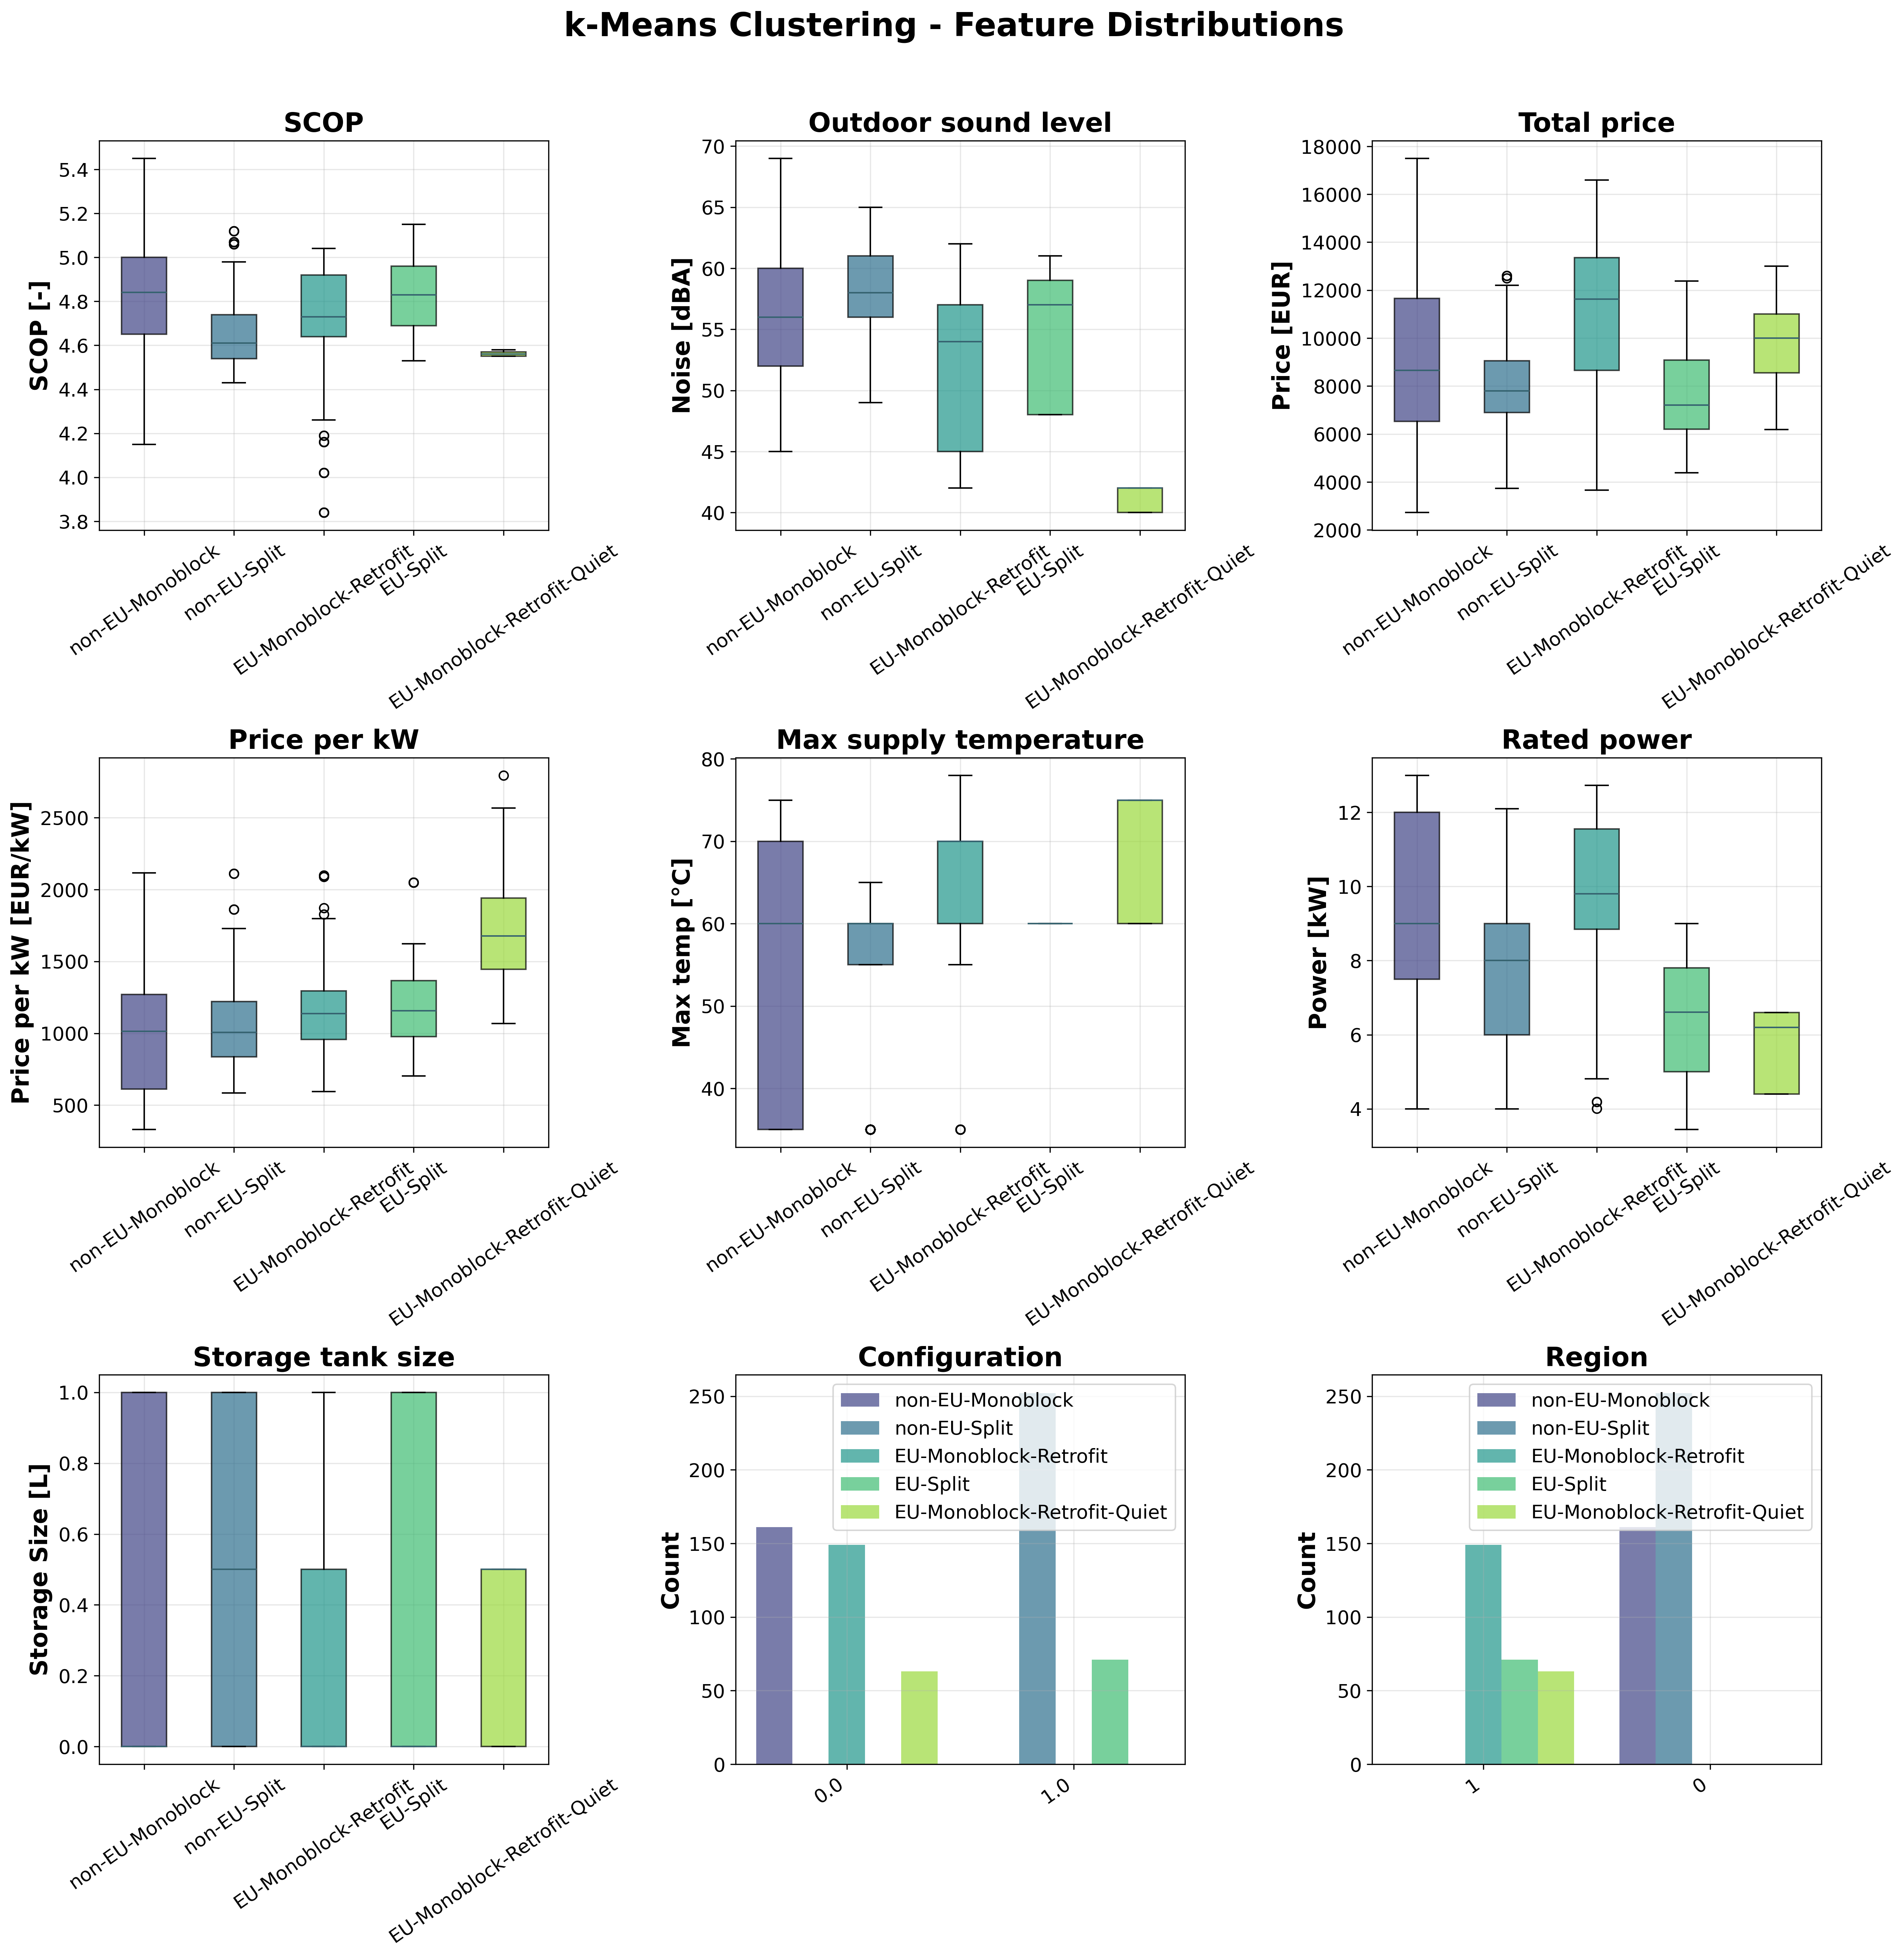

### Cluster Characteristics

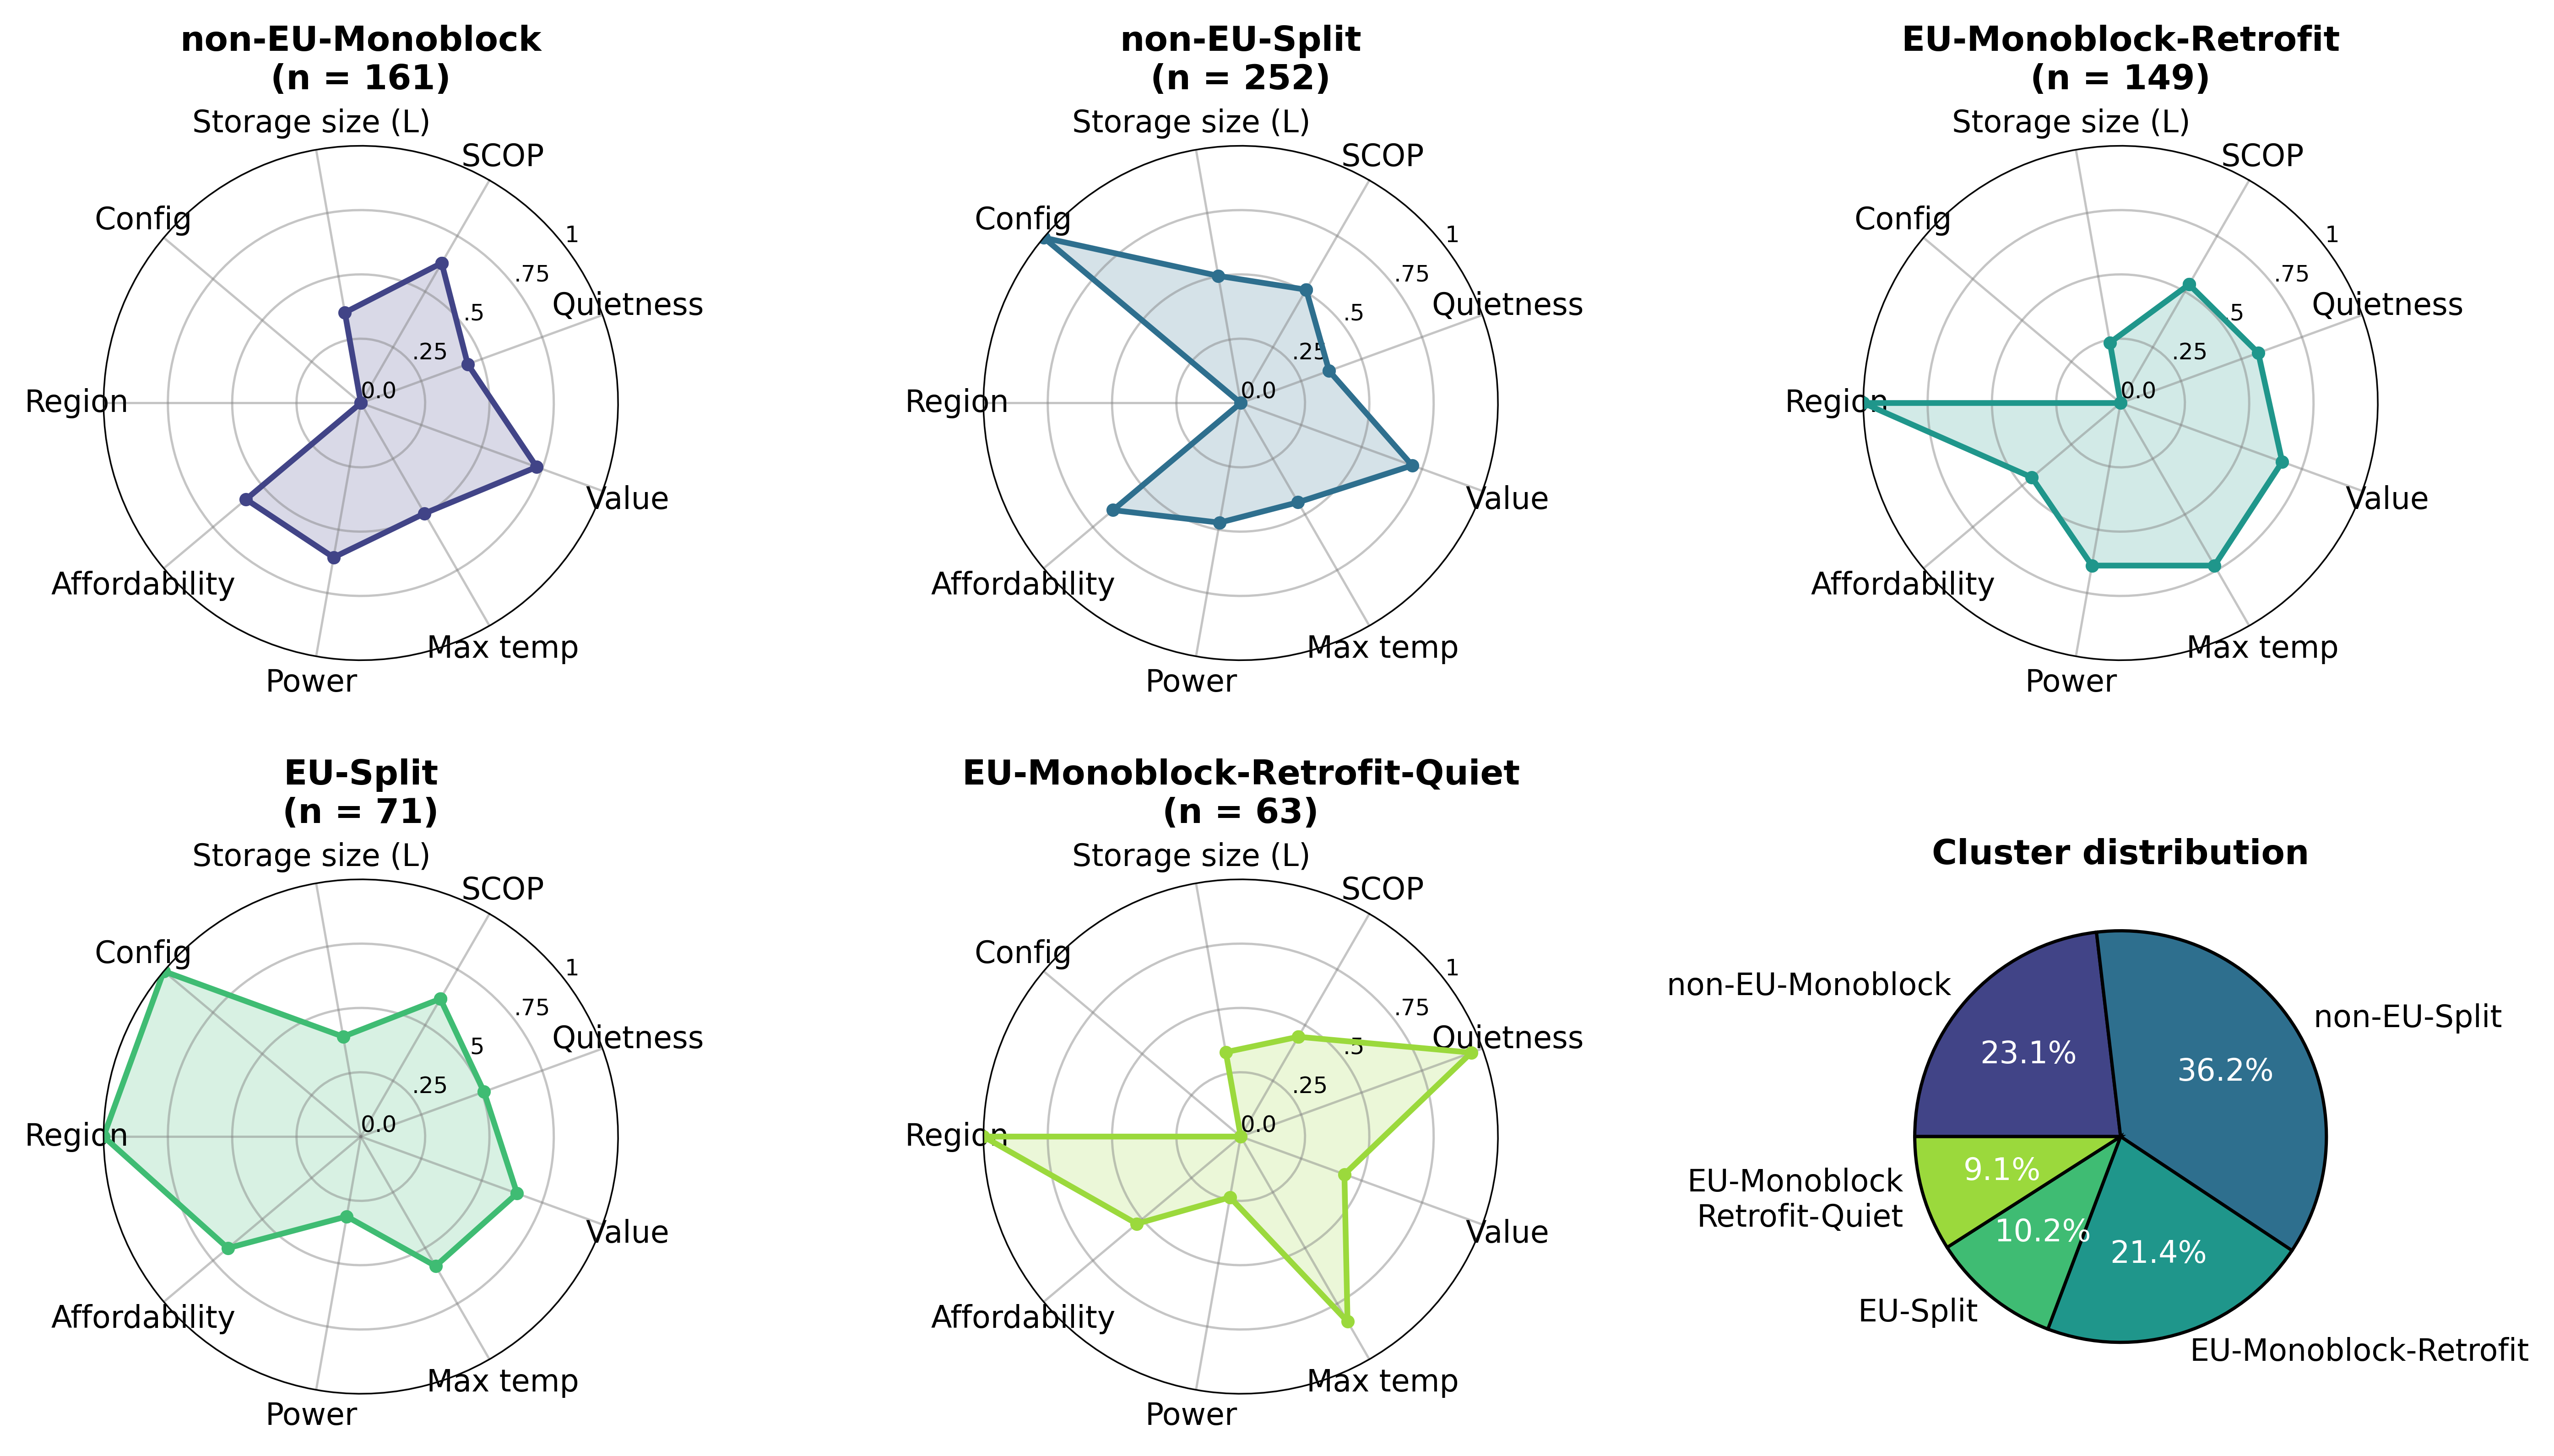

In [22]:
# Create visualizations (files are saved) and display them inline

method_label = f"K-means (Final k={n_clusters})"
create_cluster_visualizations(df_final, X_scaled, feature_names, cluster_names_final, figures_dir, method_label)

# Derive the sanitized method directory name exactly as in module
safe_method_name = method_label.lower().replace('-', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
method_dir = figures_dir / safe_method_name


image_files = [
    # 'pca_clusters.png',
    'feature_distributions_boxplot.png',  # Now includes Config, Region, and Storage Size
    # 'feature_distributions_violin.png',
    'cluster_characteristics.png',
    # 'price_vs_efficiency.png',
    # 'market_segments.png',
]

for img in image_files:
    path = method_dir / img
    display(Markdown(f"### {img.replace('_', ' ').replace('.png','').title()}"))
    display(Image(filename=str(path)))


In [23]:
# Create marketing analysis report and preview it

report_path = cmp.create_marketing_analysis_report(df_final, cluster_names_final, figures_dir)

print(report_path)
print('\n--- Report Preview ---\n')
with open(report_path, 'r', encoding='utf-8') as f:
    # Show the first ~200 lines for quick review
    for i, line in enumerate(f):
        if i > 200:
            print('... (truncated)')
            break
        print(line.rstrip())



Creating marketing analysis report...
Marketing analysis report saved to: ..\..\reports\figures\cluster_market_personalities\marketing_analysis_report.txt
..\..\reports\figures\cluster_market_personalities\marketing_analysis_report.txt

--- Report Preview ---

HEAT PUMP MARKET PERSONALITY ANALYSIS

EXECUTIVE SUMMARY
--------------------
Total market analyzed: 696 heat pump products
Number of market segments identified: 5
Analysis based on performance and pricing characteristics

DETAILED MARKET SEGMENT ANALYSIS
-----------------------------------

1. NON-EU-MONOBLOCK
Market Share: 23.1% (161 products)
Value Share: 23.1% of total market value
Average Price: 8,894 EUR
Key Performance Indicators:
  - Average SCOP: 4.85
  - Average Noise: 56.2 dBA
  - Average Power: 9.3 kW
  - Average Max Temperature: 56°C
  - Price range: 2,725 - 17,499 EUR
Leading Manufacturers:
  -  DAIKIN Europe N.V.: 44 products (27.3%)
  -  LG Electronics Inc.: 41 products (25.5%)
  -  Samsung Electronics Air Condit